# Suscripciones móviles en América
Bautista Janampa José_20220430

## Evaluación Individual 1

En este trabajo se estudia la variable `mobiles`, que registra el número de suscripciones de telefonía móvil por país. Para representarla se elaboran los tres mapas temáticos vistos en clase: un mapa de densidad de puntos, un mapa de símbolos proporcionales y una coropleta.

Los dos primeros mapas muestran cantidades totales. La coropleta responde una pregunta diferente, pues compara las suscripciones con la población de cada país. Conviene recordar que una suscripción no equivale necesariamente a una persona: alguien puede tener más de una línea móvil.

## Preparación del entorno

El cuaderno está preparado para ejecutarse en Google Colab, sin embargo se desarrolló en VS Code previa autorización del profesor del curso. La primera celda instala las bibliotecas que Colab puede no tener disponibles. Después se importan únicamente las herramientas utilizadas en el análisis.

In [1]:
%%capture
%pip install -q geopandas mapclassify thefuzz pyogrio

In [2]:
import geopandas as gpd
import mapclassify
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from thefuzz.process import extractOne as best

## Los archivos de trabajo

El GeoPackage contiene varias capas espaciales, mientras que el CSV reúne los indicadores de los países. Se utilizan los mismos archivos entregados para la evaluación y se accede a ellos desde el repositorio de datos del curso, tal como se hizo en clase.

In [3]:
linkGit = "https://github.com/CienciaDeDatosEspacial/dataSets/raw/main/"
linkWorldMaps = "WORLD/worldMaps.gpkg"
someDataLink = "WORLD/some_dataworld.csv"

Antes de leer el mapa se revisan sus capas. El resultado debe incluir `rivers`, `cities` y `countries`; para este trabajo solamente se necesita la última.

In [4]:
gpd.list_layers(linkGit + linkWorldMaps)

,name,geometry_type
0,rivers,MultiLineString
1,cities,Point
2,countries,MultiPolygon


In [5]:
countries = gpd.read_file(
    linkGit + linkWorldMaps,
    layer="countries"
)

countries.head()

,COUNTRY,geometry
0,Aruba (Netherlands),"MULTIPOLYGON (((-69.88223 12.41111, -69.94695 ..."
1,Antigua and Barbuda,"MULTIPOLYGON (((-61.73889 17.54055, -61.75195 ..."
2,Afghanistan,"MULTIPOLYGON (((61.27656 35.60725, 61.29638 35..."
3,Algeria,"MULTIPOLYGON (((-5.15213 30.18047, -5.13917 30..."
4,Azerbaijan,"MULTIPOLYGON (((46.54037 38.87559, 46.49554 38..."


El mapa tiene una columna con el nombre del país y otra con su geometría. Su sistema de referencia inicial es WGS 84 (`EPSG:4326`).

In [6]:
countries.info()
print("CRS:", countries.crs)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   COUNTRY   252 non-null    str     
 1   geometry  252 non-null    geometry
dtypes: geometry(1), str(1)
memory usage: 4.1 KB
CRS: EPSG:4326


La tabla contiene las variables sociales que faltan en el mapa. Se leen sus primeras filas y se revisan los tipos de datos antes de realizar la unión.

In [7]:
someData = pd.read_csv(linkGit + someDataLink)
someData.head()

,Country,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles
0,AFGHANISTAN,AF,AFG,SOUTH ASIA,105.0,7893000,652230,68,40121552,23000000
1,ALBANIA,AL,ALB,EUROPE,58.9,3794000,28748,3,3107100,2610000
2,ALGERIA,DZ,DZA,AFRICA,75.4,151633000,2381740,95,47022473,51500000
3,ANGOLA,AO,AGO,AFRICA,87.8,19362000,1246700,107,37202061,25700000
4,ANTIGUA AND BARBUDA,AG,ATG,CENTRAL AMERICA AND THE CARIBBEAN,54.4,729000,443,4,102634,184000


In [8]:
someData.info()

<class 'pandas.DataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       172 non-null    str    
 1   iso2          171 non-null    str    
 2   iso3          172 non-null    str    
 3   region        172 non-null    str    
 4   fragility     172 non-null    float64
 5   co2           172 non-null    int64  
 6   sq_km         172 non-null    int64  
 7   num_airports  172 non-null    int64  
 8   population    172 non-null    int64  
 9   mobiles       172 non-null    int64  
dtypes: float64(1), int64(5), str(4)
memory usage: 13.6 KB


## Una revisión antes de unir

Los mapas necesitan las columnas `Country`, `region`, `mobiles`, `population` y `sq_km`. La siguiente comprobación permite detectar a tiempo una columna ausente, países repetidos, valores faltantes o cantidades imposibles.

In [9]:
requiredColumns = ["Country", "region", "mobiles", "population", "sq_km"]
missingColumns = set(requiredColumns) - set(someData.columns)

assert not missingColumns, f"Faltan columnas: {missingColumns}"

dataReview = pd.DataFrame({
    "valores_faltantes": someData[requiredColumns].isna().sum(),
    "tipo_de_dato": someData[requiredColumns].dtypes.astype(str)
})

print("Países duplicados:", someData["Country"].duplicated().sum())
print("MOBILES no positivos:", (someData["mobiles"] <= 0).sum())
print("POPULATION no positivos:", (someData["population"] <= 0).sum())
print("SQ_KM no positivos:", (someData["sq_km"] <= 0).sum())

dataReview

Países duplicados: 0
MOBILES no positivos: 0
POPULATION no positivos: 0
SQ_KM no positivos: 0


,valores_faltantes,tipo_de_dato
Country,0,str
region,0,str
mobiles,0,int64
population,0,int64
sq_km,0,int64


Los datos necesarios están completos, pero todavía no se pueden unir directamente. La llave se llama `COUNTRY` en el mapa y `Country` en la tabla. Además, los nombres deben tener el mismo uso de mayúsculas y espacios.

In [10]:
countries.rename(columns={"COUNTRY": "Country"}, inplace=True)

countries["Country"] = countries["Country"].str.upper().str.strip()
someData["Country"] = someData["Country"].str.upper().str.strip()

## Resolver los nombres que no coinciden

Aunque las dos llaves ya tienen el mismo formato, algunos países conservan nombres diferentes. Se calculan los nombres que aparecen solamente en la tabla y los que aparecen solamente en el mapa.

In [11]:
onlyDF = set(someData.Country) - set(countries.Country)
onlyGDF = set(countries.Country) - set(someData.Country)

print("Sin coincidencia en el mapa:", len(onlyDF))
print("Sin coincidencia en la tabla:", len(onlyGDF))

Sin coincidencia en el mapa: 30
Sin coincidencia en la tabla: 110


Para encontrar posibles equivalencias se usa *fuzzy matching*. El algoritmo compara la escritura de cada nombre y devuelve la alternativa más parecida junto con una puntuación. Esta puntuación ayuda a revisar los casos, pero no sustituye la comprobación del país: dos textos parecidos no siempre significan lo mismo.

In [12]:
fuzzyReview = pd.DataFrame(
    [(country, best(country, onlyGDF)[0], best(country, onlyGDF)[1])
     for country in onlyDF],
    columns=["Country_DF", "Propuesta_GDF", "Similitud"]
).sort_values("Similitud")

fuzzyReview

,Country_DF,Propuesta_GDF,Similitud
25,CÔTE D'IVOIRE,IVORY COAST,58
14,ESWATINI,LIECHTENSTEIN,60
24,CABO VERDE,CAPE VERDE,80
22,TIMOR-LESTE,EAST TIMOR,81
13,KOREA (THE REPUBLIC OF),SOUTH GEORGIA AND THE SOUTH SANDWICH IS (UK),86
7,LAO PEOPLE'S DEMOCRATIC REPUBLIC (THE),DOMINICAN REPUBLIC,86
6,"TANZANIA, THE UNITED REPUBLIC OF",TANZANIA,90
0,MOLDOVA (THE REPUBLIC OF),MOLDOVA,90
12,NIGER (THE),NIGER,90
10,UNITED KINGDOM OF GREAT BRITAIN AND NORTHERN I...,UNITED KINGDOM,90


La revisión revela cuatro nombres que conviene corregir manualmente antes de continuar. Son casos conocidos en los que el nombre corto, el nombre oficial o una denominación anterior podrían confundir al algoritmo.

In [13]:
manualChanges = {
    "SWAZILAND": "ESWATINI",
    "LAOS": "LAO PEOPLE'S DEMOCRATIC REPUBLIC (THE)",
    "SOUTH KOREA": "KOREA (THE REPUBLIC OF)",
    "WESTERN SAMOA": "SAMOA"
}

countries.replace(
    to_replace={"Country": manualChanges},
    inplace=True
)

,Country,geometry
0,ARUBA (NETHERLANDS),"MULTIPOLYGON (((-69.88223 12.41111, -69.94695 ..."
1,ANTIGUA AND BARBUDA,"MULTIPOLYGON (((-61.73889 17.54055, -61.75195 ..."
2,AFGHANISTAN,"MULTIPOLYGON (((61.27656 35.60725, 61.29638 35..."
3,ALGERIA,"MULTIPOLYGON (((-5.15213 30.18047, -5.13917 30..."
4,AZERBAIJAN,"MULTIPOLYGON (((46.54037 38.87559, 46.49554 38..."
...,...,...
247,SOUTH SUDAN,"MULTIPOLYGON (((34.21807 9.96458, 34.20722 9.9..."
248,INDONESIA,"MULTIPOLYGON (((123.21846 -10.80917, 123.19832..."
249,EAST TIMOR,"MULTIPOLYGON (((124.41824 -9.3001, 124.40446 -..."
250,CURACAO (NETHERLANDS),"MULTIPOLYGON (((-68.96556 12.19889, -68.91196 ..."


Con esos casos resueltos se actualiza la comparación. Las equivalencias restantes se revisan en la tabla y luego se aplican sobre el DataFrame.

In [14]:
onlyDF = set(someData.Country) - set(countries.Country)
onlyGDF = set(countries.Country) - set(someData.Country)

fuzzyReview = pd.DataFrame(
    [(country, best(country, onlyGDF)[0], best(country, onlyGDF)[1])
     for country in onlyDF],
    columns=["Country_DF", "Propuesta_GDF", "Similitud"]
).sort_values("Similitud")

fuzzyReview

,Country_DF,Propuesta_GDF,Similitud
21,CÔTE D'IVOIRE,IVORY COAST,58
20,CABO VERDE,CAPE VERDE,80
18,TIMOR-LESTE,EAST TIMOR,81
0,MOLDOVA (THE REPUBLIC OF),MOLDOVA,90
6,"TANZANIA, THE UNITED REPUBLIC OF",TANZANIA,90
1,NORTH MACEDONIA,MACEDONIA,90
2,SUDAN (THE),SUDAN,90
7,BOLIVIA (PLURINATIONAL STATE OF),BOLIVIA,90
13,IRAN (ISLAMIC REPUBLIC OF),IRAN,90
12,CONGO (THE),CONGO,90


In [15]:
changesToDF = {
    country: best(country, onlyGDF)[0]
    for country in onlyDF
}

someData.replace(
    to_replace={"Country": changesToDF},
    inplace=True
)

,Country,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles
0,AFGHANISTAN,AF,AFG,SOUTH ASIA,105.0,7893000,652230,68,40121552,23000000
1,ALBANIA,AL,ALB,EUROPE,58.9,3794000,28748,3,3107100,2610000
2,ALGERIA,DZ,DZA,AFRICA,75.4,151633000,2381740,95,47022473,51500000
3,ANGOLA,AO,AGO,AFRICA,87.8,19362000,1246700,107,37202061,25700000
4,ANTIGUA AND BARBUDA,AG,ATG,CENTRAL AMERICA AND THE CARIBBEAN,54.4,729000,443,4,102634,184000
...,...,...,...,...,...,...,...,...,...,...
167,VENEZUELA,VE,VEN,SOUTH AMERICA,90.0,76730000,912050,509,31250306,18800000
168,VIETNAM,VN,VNM,EAST AND SOUTHEAST ASIA,66.1,249929000,331210,36,105758975,131000000
169,YEMEN,YE,YEM,MIDDLE EAST,113.5,10158000,527968,37,32140443,20000000
170,ZAMBIA,ZM,ZMB,AFRICA,85.7,6798000,752618,120,20799116,21200000


Antes de unir se hace una última verificación. Si todavía quedara un país sin correspondencia, el cuaderno se detendría para evitar que desaparezca silenciosamente durante el `merge`.

In [16]:
onlyDF = set(someData.Country) - set(countries.Country)

assert not onlyDF, f"Aún existen países sin coincidencia: {onlyDF}"
print("Todos los países de la tabla encontraron una geometría.")

Todos los países de la tabla encontraron una geometría.


## El mapa y los indicadores en un mismo objeto

La unión incorpora los indicadores del CSV a las geometrías. La validación `one_to_one` comprueba que cada país aparezca una sola vez en ambos lados.

In [17]:
theMapAndData = countries.merge(
    someData,
    on="Country",
    how="inner",
    validate="one_to_one"
)

theMapAndData.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Country       172 non-null    str     
 1   geometry      172 non-null    geometry
 2   iso2          171 non-null    str     
 3   iso3          172 non-null    str     
 4   region        172 non-null    str     
 5   fragility     172 non-null    float64 
 6   co2           172 non-null    int64   
 7   sq_km         172 non-null    int64   
 8   num_airports  172 non-null    int64   
 9   population    172 non-null    int64   
 10  mobiles       172 non-null    int64   
dtypes: float64(1), geometry(1), int64(5), str(4)
memory usage: 14.9 KB


In [18]:
mergeReview = pd.Series({
    "filas_del_CSV": len(someData),
    "paises_unidos": len(theMapAndData),
    "geometrias_faltantes": theMapAndData.geometry.isna().sum(),
    "geometrias_invalidas": (~theMapAndData.geometry.is_valid).sum()
})

mergeReview

filas_del_CSV           172
paises_unidos           172
geometrias_faltantes      0
geometrias_invalidas      0
dtype: int64

## Del mundo a América

La tabla distingue las regiones mediante una columna categórica. La evaluación solicita Norteamérica, Sudamérica, Centroamérica y el Caribe, que corresponden a tres valores de `region`.

In [19]:
theMapAndData.region.value_counts()

region
AFRICA                               52
EUROPE                               37
CENTRAL AMERICA AND THE CARIBBEAN    16
MIDDLE EAST                          16
EAST AND SOUTHEAST ASIA              15
SOUTH AMERICA                        12
SOUTH ASIA                            8
AUSTRALIA AND OCEANIA                 7
CENTRAL ASIA                          6
NORTH AMERICA                         3
Name: count, dtype: int64

In [20]:
americaRegions = [
    "NORTH AMERICA",
    "SOUTH AMERICA",
    "CENTRAL AMERICA AND THE CARIBBEAN"
]

America = theMapAndData[
    theMapAndData.region.isin(americaRegions)
].copy()

America.region.value_counts()

region
CENTRAL AMERICA AND THE CARIBBEAN    16
SOUTH AMERICA                        12
NORTH AMERICA                         3
Name: count, dtype: int64

La selección reúne 31 países. Antes de construir los mapas se comprueba visualmente su extensión y se confirma que las variables y geometrías necesarias estén completas.

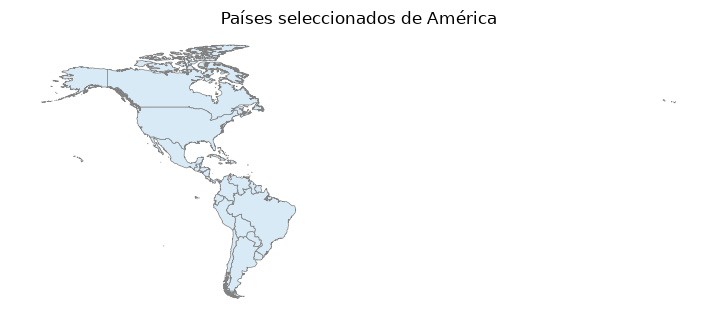

In [21]:
fig, ax = plt.subplots(figsize=(9, 9))
America.plot(
    ax=ax,
    color="#d9eaf7",
    edgecolor="grey",
    linewidth=0.5
)
ax.set_title("Países seleccionados de América")
ax.set_axis_off()
plt.show()

In [22]:
americaReview = pd.Series({
    "numero_de_paises": len(America),
    "mobiles_faltantes": America["mobiles"].isna().sum(),
    "population_faltantes": America["population"].isna().sum(),
    "geometrias_invalidas": (~America.geometry.is_valid).sum(),
    "geometrias_vacias": America.geometry.is_empty.sum()
})

americaReview

numero_de_paises        31
mobiles_faltantes        0
population_faltantes     0
geometrias_invalidas     0
geometrias_vacias        0
dtype: int64

Para los tres mapas se adopta Equal Earth (`EPSG:8857`), una proyección de igual área. Esto reduce la distorsión de las superficies y permite distribuir los puntos del DDM de una manera más coherente.

In [23]:
America_8857 = America.to_crs(8857)

x_limits = (-17_000_000, -2_000_000)
y_limits = (-6_500_000, 9_000_000)

America_8857.crs

<Projected CRS: EPSG:8857>
Name: WGS 84 / Equal Earth Greenwich
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Coordinate Operation:
- name: Equal Earth Greenwich
- method: Equal Earth
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

# 1. Mapa de densidad de puntos

En un DDM todos los puntos tienen el mismo tamaño y el mismo valor. Aquí, cada punto representa 100 000 suscripciones móviles. Esta unidad mantiene una cantidad legible de puntos y permite que incluso el país con menos suscripciones conserve al menos uno.

In [24]:
justDots = America_8857.copy()
dot_value = 100_000

justDots["num_dots"] = (
    justDots["mobiles"] / dot_value
).astype(int)

justDots[["Country", "mobiles", "num_dots"]].sort_values(
    "mobiles",
    ascending=False
).head(10)

,Country,mobiles,num_dots
157,UNITED STATES,386000000,3860
22,BRAZIL,213000000,2130
108,MEXICO,140000000,1400
37,COLOMBIA,87400000,874
7,ARGENTINA,62700000,627
120,PERU,41300000,413
27,CANADA,36500000,365
34,CHILE,26700000,267
65,GUATEMALA,20600000,206
161,VENEZUELA,18800000,188


Los puntos se colocan aleatoriamente dentro de cada país. Por esa razón no muestran la ubicación real de los usuarios; su función es representar la cantidad total mediante el número de puntos. La semilla `12345` permite obtener la misma distribución cada vez que se ejecuta el cuaderno.

In [25]:
justDots = justDots.sample_points(
    size=justDots["num_dots"],
    rng=12345
).explode(index_parts=True)

justDots = justDots.reset_index(drop=True)

America_dots_8857 = gpd.GeoDataFrame(
    geometry=justDots,
    crs=America_8857.crs
)

America_dots_8857.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 11508 entries, 0 to 11507
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   geometry  11508 non-null  geometry
dtypes: geometry(1)
memory usage: 90.0 KB


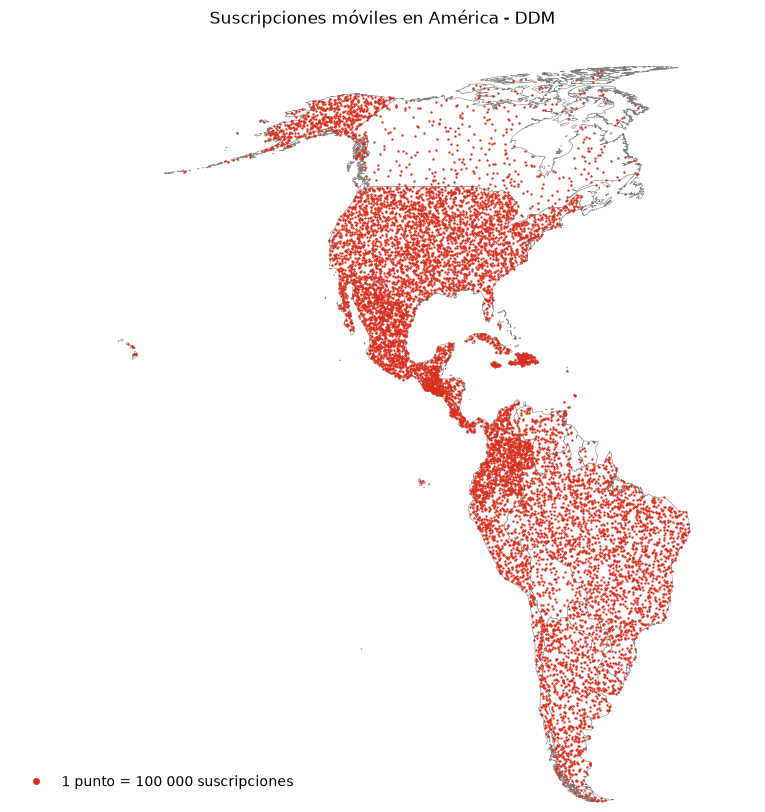

In [26]:
fig, ax = plt.subplots(figsize=(10, 10))

America_8857.plot(
    ax=ax,
    facecolor="white",
    edgecolor="grey",
    linewidth=0.4
)
America_dots_8857.plot(
    ax=ax,
    markersize=0.5,
    color="#d7301f"
)

dotLegend = Line2D(
    [0], [0],
    marker="o",
    color="none",
    markerfacecolor="#d7301f",
    markeredgecolor="none",
    markersize=5,
    label="1 punto = 100 000 suscripciones"
)

ax.legend(handles=[dotLegend], loc="lower left", frameon=False)
ax.set_title("Suscripciones móviles en América - DDM")
ax.set_xlim(*x_limits)
ax.set_ylim(*y_limits)
ax.set_axis_off()

plt.show()

El patrón está dominado por Estados Unidos, Brasil y México, que concentran gran parte de las suscripciones del continente. Esta lectura corresponde a cantidades totales: un país muy poblado tiende a reunir más puntos.

# 2. Mapa de símbolos proporcionales

El PSM vuelve a representar los valores totales, pero ahora utiliza un círculo por país. La posición se obtiene con `representative_point()`, que garantiza que el símbolo quede dentro de la geometría aun cuando el país esté formado por varias islas.

In [27]:
America_8857_centroids = America_8857.copy()
America_8857_centroids["geometry"] = (
    America_8857.representative_point()
)
America_8857_centroids["size"] = (
    America_8857_centroids["mobiles"].apply(lambda x: x**0.5 / 50)
)

America_8857_centroids[["Country", "mobiles", "size"]].head()

,Country,mobiles,size
0,ANTIGUA AND BARBUDA,184000,8.579044
7,ARGENTINA,62700000,158.366663
11,BARBADOS,323000,11.366618
14,BAHAMAS,400000,12.649111
16,BELIZE,264000,10.276186


Las diferencias entre países son amplias. Un diagrama de caja permite identificar los valores atípicos y distinguirlos en el mapa, tal como se hizo en el ejemplo de clase.

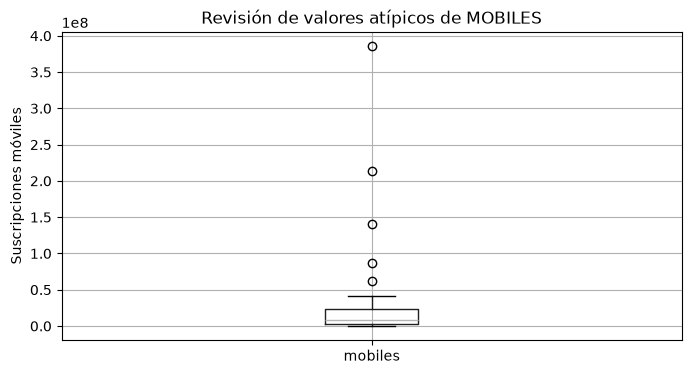

In [28]:
boxplotInfo = America_8857_centroids.boxplot(
    column="mobiles",
    return_type="dict",
    figsize=(8, 4)
)
plt.title("Revisión de valores atípicos de MOBILES")
plt.ylabel("Suscripciones móviles")
plt.show()

In [29]:
outliers = boxplotInfo["fliers"][0].get_ydata()

America_8857_centroids[
    America_8857_centroids.mobiles.isin(outliers)
][["Country", "mobiles"]].sort_values(
    "mobiles",
    ascending=False
)

,Country,mobiles
157,UNITED STATES,386000000
22,BRAZIL,213000000
108,MEXICO,140000000
37,COLOMBIA,87400000
7,ARGENTINA,62700000


In [30]:
America_8857_centroids["mobiles_outlier"] = (
    America_8857_centroids.mobiles.isin(outliers) * 1
)

America_8857_centroids_out = America_8857_centroids[
    America_8857_centroids.mobiles_outlier == 1
].copy()

America_8857_centroids_no_out = America_8857_centroids[
    America_8857_centroids.mobiles_outlier == 0
].copy()

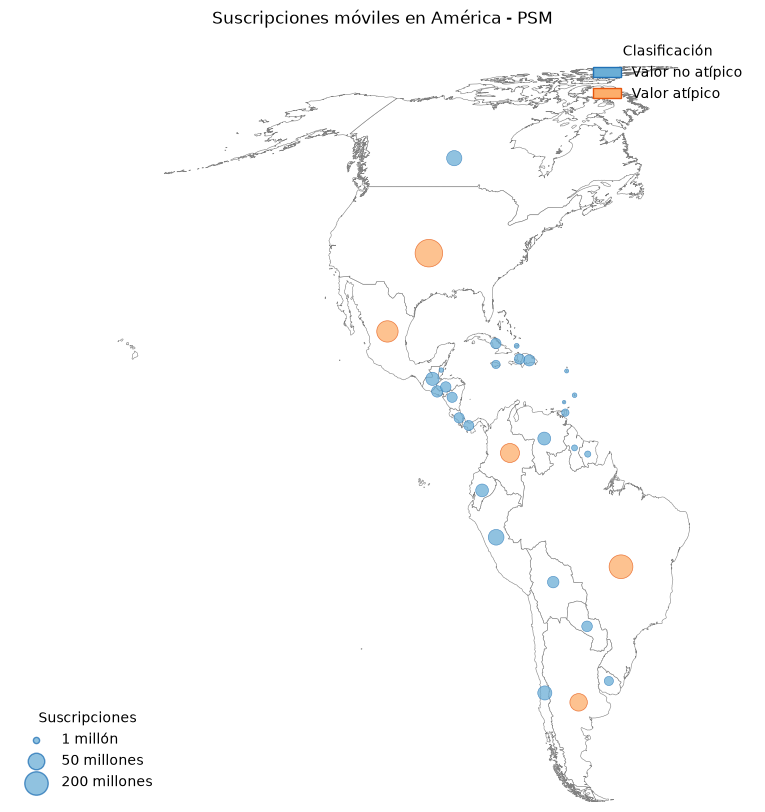

In [31]:
fig, ax = plt.subplots(figsize=(10, 10))

America_8857.plot(
    ax=ax,
    color="white",
    edgecolor="grey",
    linewidth=0.4
)
America_8857_centroids_no_out.plot(
    ax=ax,
    markersize=America_8857_centroids_no_out["size"],
    color="#6baed6",
    edgecolor="#2171b5",
    linewidth=0.4,
    alpha=0.75
)
America_8857_centroids_out.plot(
    ax=ax,
    markersize=America_8857_centroids_out["size"],
    color="#fdae6b",
    edgecolor="#e6550d",
    linewidth=0.5,
    alpha=0.75
)

sizeValues = [1_000_000, 50_000_000, 200_000_000]
sizeHandles = [
    ax.scatter(
        [], [],
        s=value**0.5 / 50,
        facecolor="#6baed6",
        edgecolor="#2171b5",
        alpha=0.75,
        label=("1 millón" if value == 1_000_000
               else f"{value/1_000_000:.0f} millones")
    )
    for value in sizeValues
]

sizeLegend = ax.legend(
    handles=sizeHandles,
    title="Suscripciones",
    loc="lower left",
    frameon=False
)
ax.add_artist(sizeLegend)

colorHandles = [
    Patch(facecolor="#6baed6", edgecolor="#2171b5",
          label="Valor no atípico"),
    Patch(facecolor="#fdae6b", edgecolor="#e6550d",
          label="Valor atípico")
]
ax.legend(
    handles=colorHandles,
    title="Clasificación",
    loc="upper right",
    frameon=False
)

ax.set_title("Suscripciones móviles en América - PSM")
ax.set_xlim(*x_limits)
ax.set_ylim(*y_limits)
ax.set_axis_off()

plt.show()

El PSM confirma el predominio de los países con mayores cantidades absolutas, pero comunica la diferencia mediante el tamaño de los círculos. Los símbolos naranjas advierten qué valores se apartan claramente del conjunto y evitan que pasen desapercibidos.

# 3. Mapa coroplético

Colorear cada país con el número bruto de suscripciones produciría una comparación condicionada por su población. Para la coropleta se utiliza una tasa: suscripciones móviles por cada 100 habitantes.

$$
\text{Suscripciones por 100 habitantes}
= \frac{\text{mobiles}}{\text{population}}\times 100
$$

El indicador puede superar 100 porque cuenta líneas móviles y no personas únicas.

In [32]:
America_8857["mobiles_per_100"] = (
    America_8857["mobiles"]
    / America_8857["population"]
    * 100
)

America_8857[
    ["Country", "mobiles", "population", "mobiles_per_100"]
].sort_values(
    "mobiles_per_100",
    ascending=False
).head(10)

,Country,mobiles,population,mobiles_per_100
0,ANTIGUA AND BARBUDA,184000,102634,179.277822
37,COLOMBIA,87400000,49588357,176.251050
52,EL SALVADOR,11500000,6628702,173.487962
123,PANAMA,6980000,4470241,156.143707
116,SURINAME,989000,646758,152.916547
145,TRINIDAD AND TOBAGO,2020000,1408966,143.367548
34,CHILE,26700000,18664652,143.051154
39,COSTA RICA,7440000,5265575,141.295110
159,URUGUAY,4800000,3425330,140.132484
7,ARGENTINA,62700000,46994384,133.420198


### Cómo se forman las clases

El indicador es continuo y se agrupa en cinco clases. Se comparan los algoritmos vistos en clase mediante la desviación absoluta alrededor de la mediana de cada clase (ADCM). Cuanto menor es el ADCM, mayor es la semejanza de los valores reunidos dentro de cada grupo.

In [33]:
np.random.seed(12345)

K = 5
theVar = America_8857["mobiles_per_100"]

ei5 = mapclassify.EqualInterval(theVar, k=K)
msd = mapclassify.StdMean(theVar)
q5 = mapclassify.Quantiles(theVar, k=K)
mb5 = mapclassify.MaximumBreaks(theVar, k=K)
ht = mapclassify.HeadTailBreaks(theVar)
fj5 = mapclassify.FisherJenks(theVar, k=K)
jc5 = mapclassify.JenksCaspall(theVar, k=K)
mp5 = mapclassify.MaxP(theVar, k=K)

d:\Python\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3748: UserWarning: Numba not installed. Using slow pure python version.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [34]:
class5 = ei5, msd, q5, mb5, ht, fj5, jc5, mp5

adcMs = pd.DataFrame({
    "ADCM": [classifier.adcm for classifier in class5],
    "Classifier": [classifier.name for classifier in class5]
}).sort_values("ADCM")

adcMs

,ADCM,Classifier
5,117.566605,FisherJenks
6,120.089921,JenksCaspall
0,141.228171,EqualInterval
3,171.556708,MaximumBreaks
2,242.239796,Quantiles
7,266.252263,MaxP
4,308.807067,HeadTailBreaks
1,367.172704,StdMean


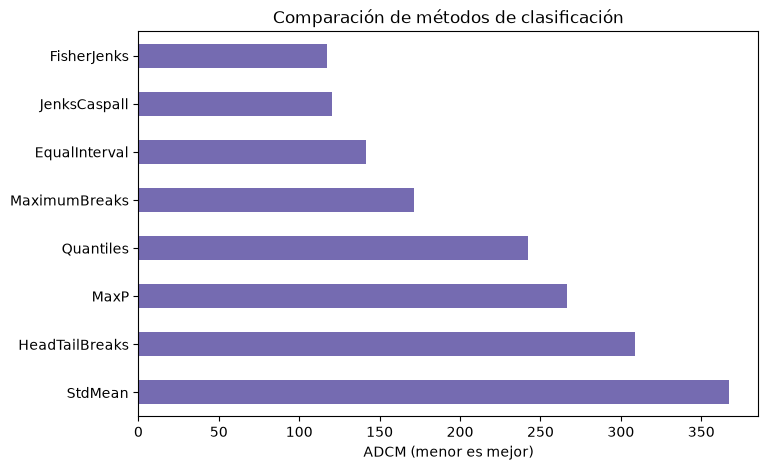

In [35]:
adcMs.sort_values("ADCM", ascending=False).plot.barh(
    x="Classifier",
    y="ADCM",
    legend=False,
    color="#756bb1",
    figsize=(8, 5)
)
plt.title("Comparación de métodos de clasificación")
plt.xlabel("ADCM (menor es mejor)")
plt.ylabel("")
plt.show()

Fisher–Jenks presenta el menor ADCM para esta variable. Por ello se utiliza su clasificación de cinco niveles en el mapa final.

In [36]:
America_8857["mobiles_per_100_FJ5"] = fj5.yb

newLabelsForLevels = {
    0: "Muy bajo",
    1: "Bajo",
    2: "Medio",
    3: "Alto",
    4: "Muy alto"
}

orderedLabels = [newLabelsForLevels[i] for i in range(K)]

America_8857["mobiles_per_100_FJ5_cat"] = pd.Categorical(
    America_8857["mobiles_per_100_FJ5"].replace(newLabelsForLevels),
    categories=orderedLabels,
    ordered=True
)

classLimits = pd.DataFrame({
    "Clase": orderedLabels,
    "Limite_superior": np.round(fj5.bins, 2)
})

classLimits

,Clase,Limite_superior
0,Muy bajo,69.94
1,Bajo,99.40
2,Medio,126.69
3,Alto,156.14
4,Muy alto,179.28


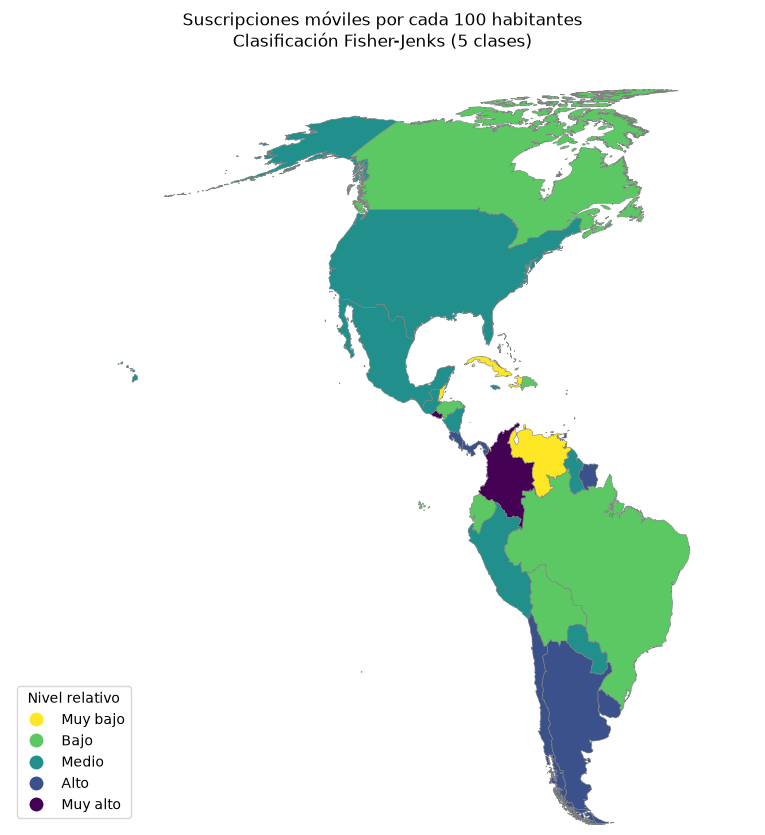

In [37]:
fig, ax = plt.subplots(figsize=(10, 10))

America_8857.plot(
    column="mobiles_per_100_FJ5_cat",
    cmap="viridis_r",
    categorical=True,
    edgecolor="grey",
    linewidth=0.4,
    legend=True,
    legend_kwds={
        "title": "Nivel relativo",
        "loc": "lower left"
    },
    ax=ax
)

ax.set_title(
    "Suscripciones móviles por cada 100 habitantes\n"
    "Clasificación Fisher-Jenks (5 clases)"
)
ax.set_xlim(*x_limits)
ax.set_ylim(*y_limits)
ax.set_axis_off()

plt.show()

## Lectura conjunta

Los tres mapas no son versiones intercambiables. El DDM y el PSM destacan dónde se concentran las mayores cantidades de suscripciones, por lo que los países más poblados tienden a dominar la imagen. La coropleta elimina buena parte de ese efecto al relacionar las suscripciones con la población y permite observar la intensidad relativa del uso móvil.

Esta diferencia explica por qué un país puede presentar un círculo pequeño en el PSM y, al mismo tiempo, pertenecer a una categoría alta en la coropleta. Tiene pocas suscripciones en términos absolutos, pero muchas en relación con su número de habitantes.